In [170]:
import numpy as np
import pandas as pd

def distribuir_votos_por_hora(total_votos=166470734, minutos_por_grupo=10, seed=42, suavidad=5):
    """
    Distribuye votos de una jornada electoral en grupos de tiempo.

    Implementa distribución por hora usando porcentajes de Caltech (2015),
    luego distribuye suavemente cada hora entre sus grupos de tiempo 
    usando Dirichlet no-homogéneo.

    Parámetros:
    -----------
    total_votos : int
        Número total de votos a distribuir (default: 166,470,734)
    minutos_por_grupo : int
        Minutos que representa cada grupo: 10, 5, o 1 (default: 10)
    seed : int
        Semilla para reproducibilidad (default: 42)
    suavidad : int
        Parámetro de concentración Dirichlet (mayor = más uniforme, default: 5)

    Retorna:
    --------
    pd.DataFrame con columnas:
        - voting_hour_12: índice del grupo (0 a num_grupos-1)
        - total_votos: cantidad de votos en ese grupo
    """

    # Establecer semilla para reproducibilidad en experimentos
    np.random.seed(seed)

    # Porcentajes de Caltech 2015 por hora (7 AM a 7 PM, 12 horas totales)
    percentages_caltech = np.array([
        15.6,  # 7-8 AM (antes de 8)
        8.7,   # 8-9 AM
        9.5,   # 9-10 AM
        11.2,  # 10-11 AM
        8.7,   # 11-12 PM
        5.4,   # 12-1 PM
        7.2,   # 1-2 PM
        6.7,   # 2-3 PM
        6.3,   # 3-4 PM
        6.7,   # 4-5 PM
        6.8,   # 5-6 PM
        5.3,   # 6-7 PM
    ])

    # Normalizar porcentajes para garantizar suma exacta de 100%
    percentages_caltech = percentages_caltech / percentages_caltech.sum() * 100

    # Obtener número de horas en la jornada electoral
    num_horas = len(percentages_caltech)

    # Calcular cantidad de votos por hora basado en porcentajes de Caltech
    votos_por_hora = (percentages_caltech / 100) * total_votos
    votos_por_hora = votos_por_hora.astype(int)

    # Ajustar primer hora para asegurar que suma total sea exacta
    votos_por_hora[0] += total_votos - votos_por_hora.sum()

    # Calcular número total de grupos y grupos por cada hora
    minutos_jornada = num_horas * 60
    num_grupos_total = int(minutos_jornada // minutos_por_grupo)
    grupos_por_hora = int(60 // minutos_por_grupo)

    # Inicializar array para almacenar distribución de votos por grupo
    votos_grupo = np.zeros(num_grupos_total, dtype=int)

    # Iterar sobre cada hora para distribuir sus votos en sus grupos
    for hora in range(num_horas):
        # Calcular índices de inicio y fin para grupos de esta hora
        inicio = hora * grupos_por_hora
        fin = inicio + grupos_por_hora

        # Generar proporciones aleatorias suaves con distribución Dirichlet
        # Dirichlet proporciona un patrón no-homogéneo sin variaciones bruscas
        parametro_dirichlet = np.ones(grupos_por_hora) * suavidad
        proporciones = np.random.dirichlet(parametro_dirichlet)

        # Distribuir votos de esta hora entre sus grupos usando proporciones
        votos_distribuidos = (proporciones * votos_por_hora[hora]).astype(int)

        # Ajustar primer grupo de hora para mantener exactitud en suma
        diferencia = votos_por_hora[hora] - votos_distribuidos.sum()
        votos_distribuidos[0] += diferencia

        # Asignar votos distribuidos a los grupos de esta hora
        votos_grupo[inicio:fin] = votos_distribuidos

    # Crear DataFrame con estructura requerida para LSTM
    df = pd.DataFrame({
        'voting_hour_12': np.arange(num_grupos_total),
        'total_votos': votos_grupo
    })

    return df


# EJEMPLO 1: Distribución con grupos de 10 minutos (72 grupos)
#df_10min = distribuir_votos_por_hora(minutos_por_grupo=10, seed=42)
#print("Distribución con 10 minutos por grupo:")
#print(f"- Número de grupos: {len(df_10min)}")
#print(f"- Total de votos: {df_10min['total_votos'].sum():,}")
#print(f"\nPrimeras 6 filas (primera hora):\n{df_10min.head(10)}")

## EJEMPLO 2: Distribución con grupos de 5 minutos (144 grupos)
#df_5min = distribuir_votos_por_hora(minutos_por_grupo=5, seed=42)
#print(f"\nDistribución con 5 minutos por grupo:")
#print(f"- Número de grupos: {len(df_5min)}")

## EJEMPLO 3: Distribución con grupos de 1 minuto (720 grupos)
#df_1min = distribuir_votos_por_hora(minutos_por_grupo=1, seed=42)
#print(f"\nDistribución con 1 minuto por grupo:")
#print(f"- Número de grupos: {len(df_1min)}")

# EJEMPLO 4: Cambiar parámetro de suavidad para variar aleatoridad
#df_suave = distribuir_votos_por_hora(minutos_por_grupo=5, suavidad=25, seed=42)
#print(f"\nDistribución con suavidad=20 (más uniforme):")
#print(f"Desviación estándar de votos: {df_suave['total_votos'].std():,.0f}")

#df_brusco = distribuir_votos_por_hora(minutos_por_grupo=10, suavidad=1, seed=42)
#print(f"\nDistribución con suavidad=1 (más variable):")
#print(f"Desviación estándar de votos: {df_brusco['total_votos'].std():,.0f}")

In [171]:
# EJEMPLO 1: Distribución con grupos de 10 minutos (72 grupos)
df_prueba = distribuir_votos_por_hora(minutos_por_grupo=5, suavidad=30, seed=42)
print("Distribución con 5 minutos por grupo:")
print(f"- Número de grupos: {len(df_prueba)}")
#print(f"- Total de votos: {df_5_suave['total_votos'].sum():,}")
print(f"\nPrimeras 12 filas (primera hora):\n{df_prueba.head(12)}")


Distribución con 5 minutos por grupo:
- Número de grupos: 144

Primeras 12 filas (primera hora):
    voting_hour_12  total_votos
0                0      2395976
1                1      2134982
2                2      2097299
3                3      2097306
4                4      2888454
5                5      2513413
6                6      2006706
7                7      2415595
8                8      2288849
9                9      1507349
10              10      1807574
11              11      2318913


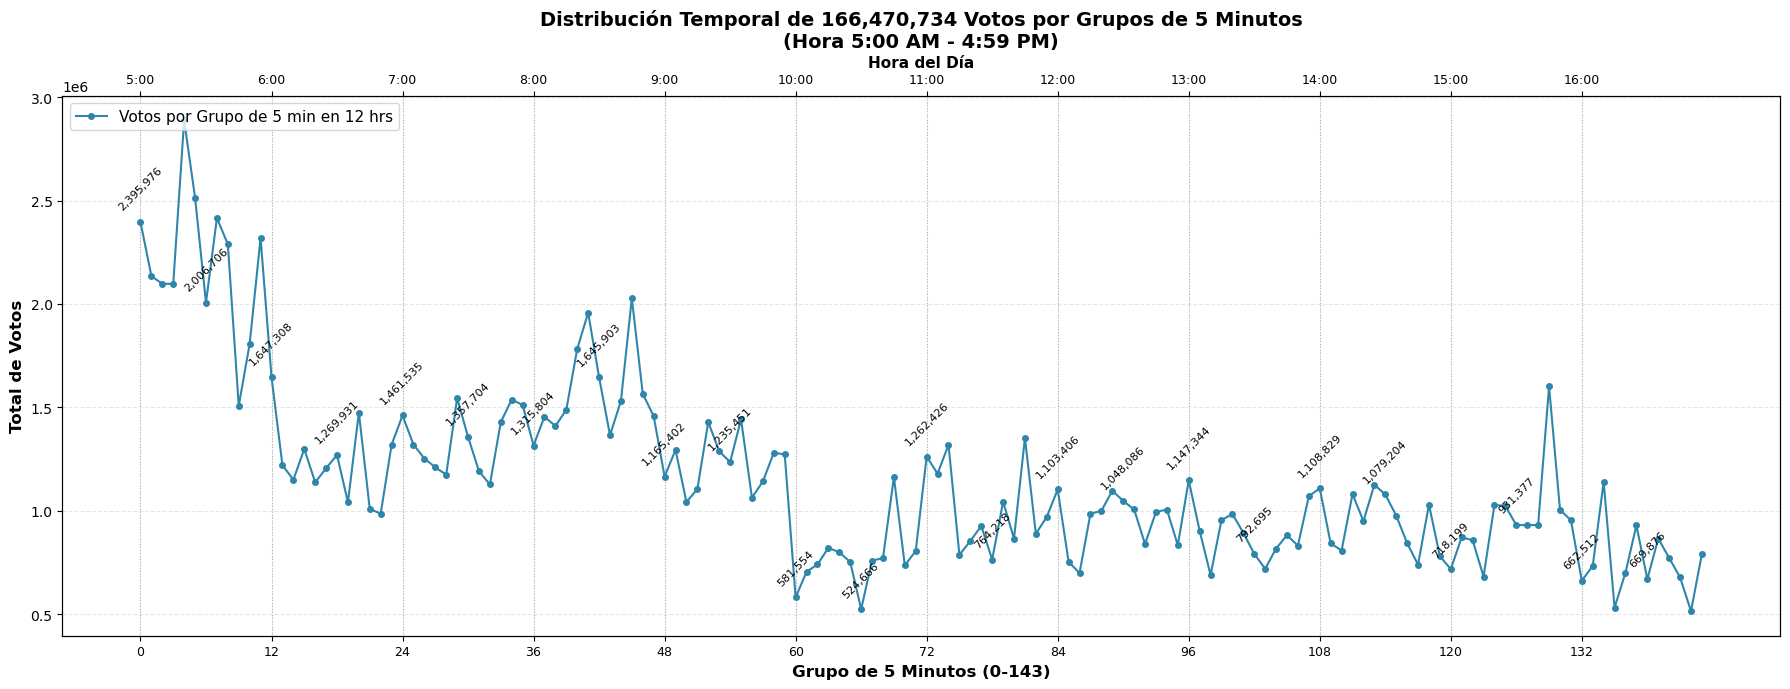


Estadísticas del gráfico:
  - Total de grupos: 144
  - Rango de grupos: 0 a 143
  - Total de votos: 166,470,734


In [172]:
import matplotlib.pyplot as plt
import numpy as np

# Correr la serie
df = distribuir_votos_por_hora(minutos_por_grupo=5, suavidad=30, seed=42)

# Extraer datos del DataFrame (tu df se llama 'df')
groups = df['voting_hour_12'].values  # Grupos de 0 a 71
series = df['total_votos'].values      # Cantidad de votos por grupo

# Crear figura más grande para 72 puntos
plt.figure(figsize=(18, 7))

# Plotear la serie de tiempo
plt.plot(groups, series, marker='o', linewidth=1.5, markersize=4, 
         color='#2E86AB', label='Votos por Grupo de 5 min en 12 hrs')

# Personalización
plt.xlabel('Grupo de 5 Minutos (0-143)', fontsize=12, fontweight='bold')
plt.ylabel('Total de Votos', fontsize=12, fontweight='bold')
plt.title('Distribución Temporal de 166,470,734 Votos por Grupos de 5 Minutos\n(Hora 5:00 AM - 4:59 PM)', 
          fontsize=14, fontweight='bold')

# Configurar el eje X para mostrar cada grupo
plt.xticks(range(0, 144, 12), fontsize=9)  # Mostrar cada 6 grupos (cada hora)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper left')

# Agregar líneas verticales cada hora (cada 12 grupos)
for h in range(0, 144, 12):
    plt.axvline(x=h, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

# Agregar etiquetas de hora en el eje X secundario
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
hora_labels = [f'{5+i}:00' for i in range(12)]  # De 5:00 AM a 16:00 (4 PM)
ax2.set_xticks(range(0, 144, 12))
ax2.set_xticklabels(hora_labels, fontsize=9)
ax2.set_xlabel('Hora del Día', fontsize=11, fontweight='bold')

# Mostrar valores solo en puntos clave (cada 12 grupos)
for i in range(0, len(groups), 6):
    plt.text(groups[i], series[i] + max(series)*0.02, 
             f'{int(series[i]):,}', ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas del gráfico:")
print(f"  - Total de grupos: {len(groups)}")
print(f"  - Rango de grupos: {groups.min()} a {groups.max()}")
print(f"  - Total de votos: {series.sum():,}")

In [70]:
df

,voting_hour_12,total_votos
0,0,2395976
1,1,2134982
2,2,2097299
3,3,2097306
4,4,2888454
...,...,...
139,139,865779
140,140,772581
141,141,678103
142,142,515136


In [183]:
# Índice para el 80%
index_80 = int(len(series) * 0.6)
# Índice para el 90% (80% + 10%) y el 10% restante
index_90 = int(len(series) * 0.75)

# Partimos la serie en función de las proporciones
train = series[:index_80]               #Entrenamiento
valid = series[index_80:index_90]             #Validación
test  = series[index_90:]              #Prueba 

#Ahora hacemos el proceso de normalización, esto poniendo los datos dentro de una escala entre 0 y 1
# 1) Tomamos la “escala” como el valor máximo observado en TRAIN
scale = float(train.max()) if float(train.max()) != 0 else 1.0

# 2) Divides cada serie por la escala → todo queda en ~[0, 1]
y_train = (train / scale).astype('float32')
y_valid = (valid / scale).astype('float32')
y_test  = (test  / scale).astype('float32')

print("Grupos definidos")
print("[Entrenamiento, validación y prueba]")
grupos = [y_train, y_valid, y_test]
grupos

Grupos definidos
[Entrenamiento, validación y prueba]


[array([0.82950115, 0.7391435 , 0.7260974 , 0.72609985, 1.        ,
        0.87015855, 0.69473356, 0.8362934 , 0.7924132 , 0.5218532 ,
        0.6257929 , 0.8028215 , 0.57030785, 0.4227303 , 0.39814863,
        0.44978595, 0.3939097 , 0.41756386, 0.4396577 , 0.3605794 ,
        0.51071614, 0.3491553 , 0.34177107, 0.45687175, 0.5059921 ,
        0.45724046, 0.43380818, 0.41910136, 0.4067193 , 0.5348439 ,
        0.4700452 , 0.41255286, 0.39032575, 0.4948038 , 0.53243846,
        0.52332145, 0.4555392 , 0.5038796 , 0.4880223 , 0.5156201 ,
        0.6172281 , 0.6778041 , 0.5698214 , 0.4728644 , 0.5301009 ,
        0.70203406, 0.5421762 , 0.5048424 , 0.40346912, 0.44834295,
        0.3608508 , 0.38265523, 0.49483564, 0.44606215, 0.42772052,
        0.49943048, 0.36832055, 0.39541292, 0.4434476 , 0.44064957,
        0.20133746, 0.24433486, 0.25647283, 0.28430885, 0.27691147,
        0.2606249 , 0.1816425 , 0.26293546, 0.26715225, 0.4026299 ,
        0.25499767, 0.27911922, 0.4370594 , 0.40

In [184]:
import tensorflow as tf
tf.random.set_seed(42)

# tamaño de la secuencia optima.
seq_length = 13
#max(2, min(56, len(y_train) - 1, len(y_valid) - 1, len(y_test) - 1))

print(seq_length)
batch_size = 16

# Función para calcular las ventanas deslizantes, la ventana maxima viable
def make_ds(series_1d, seq_len, batch=16, shuffle_input=False, seed=42):
    return tf.keras.utils.timeseries_dataset_from_array(
        data=series_1d,                # serie, ya normalizada.
        targets=series_1d[seq_len:],   # targets=series_1d[seq_len:]: define que el modelo aprende a predecir el siguiente punto a partir de la ventana de tamaño seq_len.
        sequence_length=seq_len,       # el tamaño de la ventana que tendra la mini serie de tiempo  
        batch_size=batch,              # se divide el anterior dato en 32 aleatoriamente con la semilla
        shuffle=shuffle_input,         # si se revuelve o no los datos, si es aleatoria esta batch de 32 a partir de los targets
        seed=seed                      # para asegurar reproducibilidad
    )

train_ds = make_ds(y_train, seq_length, batch_size, shuffle_input=True,  seed=42)  #se combinan para que aprenda de diferentes puntos la red
valid_ds = make_ds(y_valid, seq_length, batch_size, shuffle_input=False)           #no se combinan porque solo se predice directamente para obtener el valor de la metrica
test_ds  = make_ds(y_test,  seq_length, batch_size, shuffle_input=False)           #igual que arriba

print("seq_length usado:", seq_length)
print(train_ds)

13
seq_length usado: 13
<_BatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [186]:
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=300):
    """
    Entrena un modelo recurrente para predecir t+1.
    
    Argumentos:
        model: Modelo LSTM/RNN de Keras
        train_set: Dataset de entrenamiento (ventanas deslizantes)
        valid_set: Dataset de validación
        learning_rate: Tasa de aprendizaje para SGD
        epochs: Número máximo de épocas (iteraciones completas sobre los datos)
    
    Retorna:
        history: Historial de entrenamiento (pérdidas, métricas)
        val_mae: MAE en validación (en unidades originales, no normalizadas)
    """
    
    # Early Stopping: Detiene entrenamiento si no mejora en 50 épocas
            # Previene sobre ajuste
    cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",           # Métrica a monitorear
        patience=50,                 # Épocas sin mejora antes de detener
        restore_best_weights=True    # Restaura pesos de la mejor época
    )
    
    # Optimizador Stochastic Gradient Descent (SGD) con momentum
    opt = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,  # Tamaño del paso en la dirección del gradiente, muy alto modelo diverge, muy bajo convergencia lenta
        momentum=0.9                  # Inercia (acelera convergencia, típicamente entre 0.9-0.99), Acelera convergencia y ayuda a escapar de mínimos locales poco profundos
    )
    
    # Compilación del modelo
    model.compile(
        loss=tf.keras.losses.Huber(),  # Función híbrida que combina MSE (errores pequeños) y MAE (errores grandes), más robusta (para la compilación)
        optimizer=opt,                 # Algoritmo de optimización
        metrics=["mae"]                # Métricas adicionales a reportar   (la que se usa para compara con otros modelos)
    )
    
    # Entrenamiento
    history = model.fit(
        train_set,                    # Datos de entrenamiento
        validation_data=valid_set,    # Datos de validación
        epochs=epochs,                # Épocas máximas
        callbacks=[cb],               # Lista de callbacks
        verbose=1                     # Mostrar progreso, imprimir la salida (imprimir más)
    )
    
    # Evaluación final en validación
    _, val_mae = model.evaluate(valid_set, verbose=0)
    
    # Desnormalizar MAE
    return history, float(val_mae) * scale   # reescala a votos/hora, multimplicamos por la escala hecha anteriormente

print("Función fit_and_evaluate() definida")

Función fit_and_evaluate() definida


### Ejemplo de Salida del siguiente código, es necesario describir que está pasando

- Epoch 100/300
- 45/45 [==============================] - 0s 3ms/step - loss: 0.0045 - mae: 0.0045 - val_loss: 0.0042 - val_mae: 0.0042
- Epoch 150/300

¿Qué significa cada cosa?
- loss (perdida)  :Huber loss en el entrenamiento (dato normalizado)
- mae             :Error Medio absoluto (Normalizado)
- val_loss:       :Huber loss en validación
- val_mae:        :MAE en validación (encargado de monitorear Early Stopping)

In [187]:
tf.random.set_seed(42)

model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(
        16,                              #Dimension de las capas ocultas, entre más, también más riesgo de overfitting
        input_shape=[None, 1]),          #NONE es aceptar secuencias de cualquier longitud, el tamño de la ventana #1 es el no de caracteristicas por paso, y solo analizamos los votos
    tf.keras.layers.Dense(1)             #Solo se predice un dato de salida, la cantidad de votos en t+1 (la estructura es una unica salida y una sola capa densa)
])

hist_lstm, valid_mae_lstm = fit_and_evaluate(model_lstm, train_ds, test_ds, learning_rate=0.05, epochs=300)

print(f"Valid MAE sin normalizar (LSTM-32): {valid_mae_lstm/scale}")
print(f"Valid MAE (LSTM-32): {valid_mae_lstm:,.0f} votos/5min")



Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0515 - mae: 0.2709 - val_loss: 0.0492 - val_mae: 0.3042
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0378 - mae: 0.2545 - val_loss: 0.0196 - val_mae: 0.1885
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0121 - mae: 0.1249 - val_loss: 0.0062 - val_mae: 0.0870
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0142 - mae: 0.1370 - val_loss: 0.0110 - val_mae: 0.1383
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0097 - mae: 0.1153 - val_loss: 0.0205 - val_mae: 0.1933
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0069 - mae: 0.0935 - val_loss: 0.0035 - val_mae: 0.0630
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0072 - mae: 0.0975 - val_loss: 0.0042 - val_mae: 0.0741
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0049 - mae: 0.0770 - val_loss: 0.0113 - val_mae: 0.1402
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0056 - mae: 

In [188]:
import numpy as np

# ========== Hacer predicciones en test ==========
y_pred_lstm_norm = model_lstm.predict(test_ds, verbose=1)
y_pred_lstm = y_pred_lstm_norm.flatten() * scale  # ✓ FLATTEN

# ========== Desnormalizar test set ==========
y_test_real = y_test * scale

print(y_pred_lstm)
print(y_test_real)

# Tomar solo hasta el tamaño del más pequeño para comparar solo los datos que existe, en el de predicción 2, en el de prueba 14
min_len = min(len(y_test_real), len(y_pred_lstm))
y_test_real = y_test_real[len(y_test_real)-min_len:]
y_pred_lstm = y_pred_lstm[:min_len]

print(y_pred_lstm)
print(y_test_real)

# Calcular desviación estándar de los errores de predicción
errors = np.abs(y_test_real - y_pred_lstm)  # Error de cada predicción

print(errors)

media_error = np.mean(errors)
std_error = np.std(errors)
varianza_error = np.var(errors)
min_error = np.min(errors)
max_error = np.max(errors)

print("\n----------------------- UMBRALES DE ANOMALÍA -----------------------\n")
print(f"Media de error:        {media_error:,.0f} votos")
print(f"Desviación estándar:   {std_error:,.0f} votos")
print(f"Varianza:              {varianza_error:,.0f} votos²")
print(f"Error mínimo:          {min_error:,.0f} votos")
print(f"Error máximo:          {max_error:,.0f} votos")

# ========== Calcular Naive MAE ==========
mean_votes_train = train.mean()
naive_mae = np.mean(np.abs(y_test_real - mean_votes_train))

print("\n----------------------- COMPARACIÓN LSTM vs BASELINE -----------------------\n")
print(f"Naive MAE (predecir media):  {naive_mae:,.0f} votos/5min")
print(f"LSTM MAE (tu modelo):        {valid_mae_lstm:,.0f} votos/5min")
print(f"Mejora LSTM vs Baseline:     {naive_mae/valid_mae_lstm:.1f}x MEJOR")

# ========== Umbrales de anomalía para una distribución normal ==========
threshold_1sigma = media_error + std_error
threshold_2sigma = media_error + 2 * std_error      #El limite superior de una distribucion normal, donde se tiene que encontrar el 95% de los datos de una distribución normal
threshold_3sigma = media_error + 3 * std_error

print("\n----------------------- UMBRALES DE ANOMALÍA -----------------------\n")
print("Los errores tienen que ser mayores que el 95% de los datos de una distribución normal", "anomalias = errors > threshold_2sigma\n")
print(f"Rango normal (1σ):   0 - {threshold_1sigma:,.0f} votos (68% de casos)")
print(f"Rango raro (2σ):     0 - {threshold_2sigma:,.0f} votos (95% de casos)     METRICA IMPORTANTE, TIENE QUE SER MENOR QUE ESTE VALOR")
print(f"Rango anómalo (3σ):  > {threshold_3sigma:,.0f} votos (anomalía probable)")

# ========== Detectar anomalías ==========
#anomalias = errors > threshold_2sigma

#for elem in range(len(errors)):
#    print(f"El error numero {elem+1} es {errors[elem]:,.0f}")

#print("Entonces las anomalias son:", anomalias)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
[ 883687.7   890160.44  890684.1   857731.44  902169.9   930372.1
  933613.1   937119.6   939673.75 1070117.2  1043180.2  1020821.2
  948035.3   911069.6   960959.2   876021.25  853435.56  878715.44
  845262.7   861745.75  854044.8   831479.6   784425.94]
[1108829.    842757.    808335.   1080983.    950528.   1126233.
 1079204.    977431.    844450.94  739858.   1030068.    780883.
  718199.    872755.94  857681.    682674.   1028748.06 1023575.
  931377.06  931170.    931379.   1601475.   1006057.    954164.
  662512.    733322.   1140040.    532369.    701668.    929764.
  669876.    865778.94  772581.    678103.    515136.03  792681.06]
[ 883687.7   890160.44  890684.1   857731.44  902169.9   930372.1
  933613.1   937119.6   939673.75 1070117.2  1043180.2  1020821.2
  948035.3   911069.6   960959.2   876021.25  853435.56  878715.44
  845262.7   861745.75  854044.8   831479.6   784425.94]
[ 872755.94  857681.    682674.   1028748.06 1023575.   

In [189]:
print(f"\n" + "=" * 70)
print(f"ANOMALÍAS DETECTADAS (2σ umbral)")
print(f"=" * 70)
print(f"Total de predicciones: {len(errors)}")
print(f"Anomalías encontradas: {np.sum(anomalias)}")

# ✓ CORRECCIÓN: np.where devuelve tupla, usar [0]
if np.any(anomalias):
    print("\nDetalles de anomalías:")
    anomaly_indices = np.where(anomalias)[0]  # ✓ CORRECTO
    
    for idx in anomaly_indices:  # ✓ CORRECTO: iterar sobre índices
        grupo = 130 + idx
        print(f"\n  Grupo #{grupo} (índice {idx}):")
        print(f"    Votos reales:        {y_test_real[idx]:,.0f}")
        print(f"    Votos predichos:     {y_pred_test[idx]:,.0f}")
        print(f"    Error de predicción: {errors[idx]:,.0f} (> {threshold_2sigma:,.0f})")
        sigma_deviations = (errors[idx] - media_error) / std_error
        print(f"    Desviaciones sigma:  {sigma_deviations:.2f}σ (anómalo si > 2)")


ANOMALÍAS DETECTADAS (2σ umbral)
Total de predicciones: 23
Anomalías encontradas: 0


NameError: name 'intervalos' is not defined

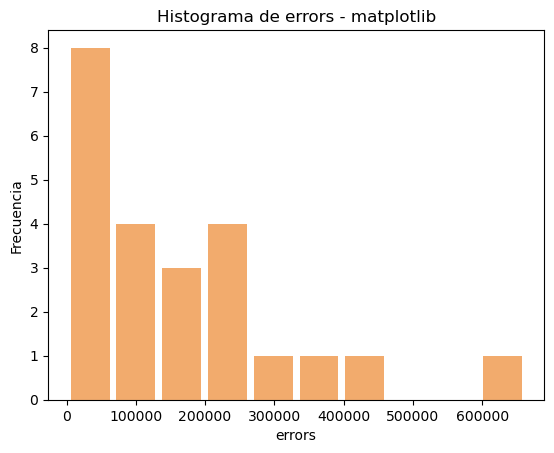

In [196]:
import matplotlib.pyplot as plot

plot.hist(x=errors, color='#F2AB6D', rwidth=0.85)
plot.title('Histograma de errors - matplotlib')
plot.xlabel('errors')
plot.ylabel('Frecuencia')
plot.xticks(intervalos)

plot.show() #dibujamos el histograma

In [193]:
print(errors)

[ 10931.75    32479.438  208010.12   171016.62   121405.125    1004.9375
   2443.125    5740.625  661801.25    64060.25    89016.19   358309.2
 214713.31   228970.38   428590.2    174353.25    76328.44   208839.44
  20516.25    89164.75   175941.81   316343.6      8255.125 ]


[ 9.299427  10.388363  12.245342  12.049516  11.706888   6.9126806
  7.801033   8.655323  13.40272   11.067579  11.396573  12.789151
 12.277059  12.341348  12.968257  12.068839  11.242801  12.249321
  9.928972  11.398241  12.0779085 12.664584   9.01859  ]


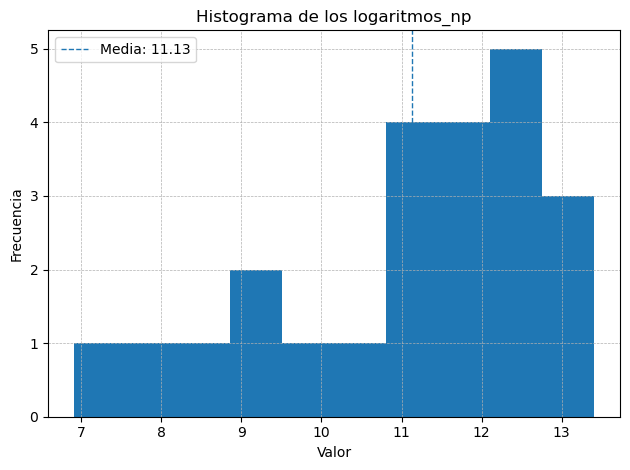

In [200]:
# Importa numpy para manejar arreglos numéricos
import numpy as np
# Importa matplotlib.pyplot para graficar
import matplotlib.pyplot as plt

# Define la función que crea el histograma
def graficar_histograma(valores, bins='auto', titulo='Histograma de valores', mostrar_media=True, guardar_png=None):
    """
    Genera un histograma a partir de una lista o arreglo de valores.

    Parámetros
    ----------
    valores : list | np.ndarray
        Colección de números a graficar en el histograma.
    bins : int | str, opcional
        Número de contenedores (p. ej., 10) o estrategia ('auto', 'fd', 'sturges', etc.). Por defecto 'auto'.
    titulo : str, opcional
        Título que aparecerá en la gráfica.
    mostrar_media : bool, opcional
        Si True, dibuja una línea vertical indicando la media y la muestra en la leyenda.
    guardar_png : str | None, opcional
        Ruta de archivo para guardar la imagen (p. ej., 'histograma.png'). Si None, no guarda archivo.
    """
    # Convierte la entrada a un arreglo de numpy
    arr = np.asarray(valores)

    # Crea la figura
    plt.figure()

    # Dibuja el histograma (sin especificar colores)
    plt.hist(arr, bins=bins)

    # Coloca el título
    plt.title(titulo)

    # Etiqueta el eje X
    plt.xlabel('Valor')

    # Etiqueta el eje Y
    plt.ylabel('Frecuencia')

    # Activa la grilla para facilitar lectura
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Si se solicita, calcula la media y dibuja una línea vertical
    if mostrar_media:
        # Calcula la media
        media = arr.mean()
        # Dibuja una línea vertical en la media (sin especificar color)
        plt.axvline(media, linestyle='--', linewidth=1, label=f'Media: {media:,.2f}')
        # Muestra la leyenda
        plt.legend()

    # Ajusta márgenes automáticamente
    plt.tight_layout()

    # Si se indicó una ruta, guarda la figura como PNG
    if guardar_png:
        # Guarda la figura en el archivo especificado
        plt.savefig(guardar_png, dpi=150)

    # Muestra la gráfica en pantalla
    plt.show()

logaritmos_np = np.log(errors)
print(logaritmos_np)

# Define los datos provistos (lista de valores)
valores = [
    10931.75, 32479.438, 208010.12, 171016.62, 121405.125, 1004.9375,
    2443.125, 5740.625, 661801.25, 64060.25, 89016.19, 358309.2,
    214713.31, 228970.38, 428590.2, 174353.25, 76328.44, 208839.44,
    20516.25, 89164.75, 175941.81, 316343.6, 8255.125
]


# Llama a la función para graficar el histograma con 10 bins
graficar_histograma(logaritmos_np, bins=10, titulo='Histograma de los logaritmos_np', mostrar_media=True, guardar_png=None)


In [206]:
from scipy import stats

shape_est, loc_est, scale_est = stats.gamma.fit(errors)
print(f"Estimated shape parameter (alpha): {shape_est}")
print(f"Estimated location parameter: {loc_est}")
print(f"Estimated scale parameter (beta): {scale_est}")

Estimated shape parameter (alpha): 0.4490962922526728
Estimated location parameter: 1004.937449429774
Estimated scale parameter (beta): 259122.59508431813


In [207]:
print(shape_est*(scale_est)**2)

30154354655.18735


In [213]:
media_gamma = (shape_est*scale_est)+loc_est
print(media_gamma)

117375.9341406877


In [210]:
desviacion_gammma = np.sqrt(shape_est*(scale_est)**2)
print(desviacion_gammma)

173650.09258617557


In [216]:
threshold_2sigma = media_gamma + 2 * desviacion_gammma   
print("maximo valor para el threshold", threshold_2sigma)

maximo valor para el threshold 464676.1193130388


{'whiskers': [<matplotlib.lines.Line2D at 0x74e6302eb2d0>,
 'caps': [<matplotlib.lines.Line2D at 0x74e6302e8490>,
 'boxes': [<matplotlib.lines.Line2D at 0x74e630851a50>],
 'medians': [<matplotlib.lines.Line2D at 0x74e6302e1e90>],
 'fliers': [<matplotlib.lines.Line2D at 0x74e6302e0690>],
 'means': []}

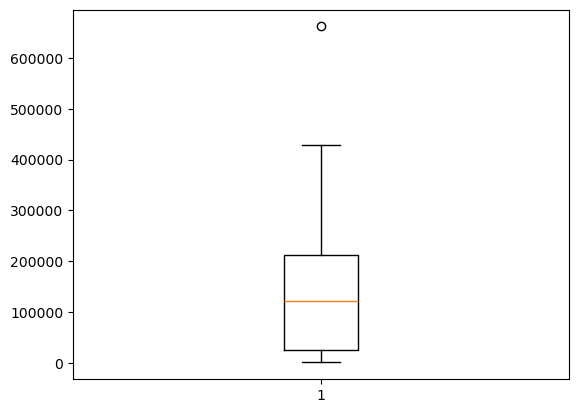

In [217]:
plt.boxplot(errors)

#me tomo el primero y tercer quantil, el primer -+ el rango intercuantil 1.5, solo como referencia